# Vector Auto Regresive (VAR)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../Data/gold/covid_multivariate_w_2.csv')
df.head()

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated
0,2020-03-23,Chile,1558,10261,5.828571,5.242857,10.619048,28.350649,37.952381,3.773810,19331414,19.456667,69.844286,0.0
1,2020-03-30,Chile,2420,24909,5.978571,6.516667,13.771429,38.922078,50.726190,4.035714,19331414,12.998571,75.930000,0.0
2,2020-04-06,Chile,2987,43938,6.235714,6.992857,12.733333,43.142857,66.071429,3.840476,19331414,11.041429,75.930000,0.0
3,2020-04-13,Chile,3304,65523,7.383333,8.771429,11.707143,43.233766,69.059524,4.076190,19331414,10.270000,75.930000,0.0
4,2020-04-20,Chile,4054,90640,6.742857,6.788095,11.769048,38.662338,63.321429,3.661905,19331414,10.878571,75.930000,0.0


In [4]:
df['date'] = pd.to_datetime(df['date'])

In [6]:
df.columns

Index(['date', 'country', 'new_cases', 'cases', 'co', 'no2', 'o3', 'pm10',
       'pm25', 'so2', 'population', 'Mean_distance_avg_14day_movavg',
       'StringencyIndex_Average', 'pop_vaccinated'],
      dtype='object')

# Experiment

In [104]:
df_var = df[df['country'] == 'Colombia']
df_var = df_var[['date', 'cases',  'pm25', 'Mean_distance_avg_14day_movavg', 'StringencyIndex_Average', 'pop_vaccinated']]
df_var.set_index('date', inplace=True)

In [105]:
import statsmodels.api as sm
from statsmodels.tsa.api import VAR

In [106]:
# Fit a VAR model
model = VAR(df_var)
results = model.fit(maxlags=5)  # Choose lag length (5 lags)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 25, Mar, 2025
Time:                     09:44:56
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                    27.2076
Nobs:                     140.000    HQIC:                   25.5861
Log likelihood:          -2576.58    FPE:                4.35810e+10
AIC:                      24.4761    Det(Omega_mle):     1.85950e+10
--------------------------------------------------------------------
Results for equation cases
                                       coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------------------------
const                                -12588.103337     84572.055844           -0.149           0.882
L1.cases                                  2.920487         0.095777           30.

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


In [107]:
df_var['pop_vaccinated'] = df_var['pop_vaccinated'].replace(0,0.1)
df_var['StringencyIndex_Average'] = df_var['StringencyIndex_Average'].replace(0,0.1)

In [108]:
# log of variables
df_var_log = np.log(df_var).diff()
df_var_log.dropna(inplace=True)
df_var_log.head()


,cases,pm25,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated
date,,,,,
2020-03-30,0.847669,-0.626573,-0.550255,0.117978,0.0
2020-04-06,0.656505,-0.527920,-0.473495,0.000000,0.0
2020-04-13,0.389521,0.696017,-0.313713,-0.036721,0.0
2020-04-20,0.343140,-0.334945,0.110046,0.007787,0.0
2020-04-27,0.353845,0.040555,0.182322,0.060050,0.0


In [109]:
# Fit a VAR model
model_l = VAR(df_var_log)
results_l = model_l.fit(maxlags=5)  # Choose lag length (5 lags)
results_l.summary()

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 25, Mar, 2025
Time:                     09:45:12
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   -25.0684
Nobs:                     139.000    HQIC:                  -26.6976
Log likelihood:           1076.83    FPE:                8.52540e-13
AIC:                     -27.8128    Det(Omega_mle):     3.61717e-13
--------------------------------------------------------------------
Results for equation cases
                                       coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------------------------
const                                     0.000315         0.001029            0.306           0.760
L1.cases                                  1.155759         0.093568           12.

# All countries

In [110]:
def extract_significant_vars(results, target='cases', alpha=0.05):
    # Get the parameters, standard errors, t-statistics, and p-values
    params = results.params[target]
    stderr = results.stderr[target]
    tvalues = results.tvalues[target]
    pvalues = results.pvalues[target]

    # Combine into a DataFrame
    df = pd.DataFrame({
        'Variable': params.index,
        'Coefficient': params.values,
        'Std. Error': stderr.values,
        't-value': tvalues.values,
        'P-value': pvalues.values
    })

    # Filter significant variables (p-value < alpha)
    significant_df = df[df['P-value'] < alpha]

    return significant_df


In [111]:
df.columns

Index(['date', 'country', 'new_cases', 'cases', 'co', 'no2', 'o3', 'pm10',
       'pm25', 'so2', 'population', 'Mean_distance_avg_14day_movavg',
       'StringencyIndex_Average', 'pop_vaccinated'],
      dtype='object')

In [125]:
countries = df['country'].unique()

dict_results = {}
target = 'cases'
#target = 'new_cases'
# loop mock
for country in countries:
    print(country)
    df_var = df[df['country']==country]
    df_var = df_var[['date', target, 'pm25', 'no2', 'o3' ,'Mean_distance_avg_14day_movavg', 'StringencyIndex_Average', 'pop_vaccinated']]
    df_var.set_index('date', inplace=True)
    df_var['pop_vaccinated'] = df_var['pop_vaccinated'].replace(0,0.1)
    df_var['StringencyIndex_Average'] = df_var['StringencyIndex_Average'].replace(0,0.1)

    df_var[target] = df_var[target].replace(0,0.1)
    df_var_log = np.log(df_var).diff()
    df_var_log.dropna(inplace=True)
    model_l = VAR(df_var_log)
    results_l = model_l.fit(maxlags=5)  # Choose lag length (5 lags)
    significant_vars_cases = extract_significant_vars(results_l, target=target, alpha=0.05)
    dict_results[country] = significant_vars_cases['Variable'].values


Chile
Colombia
Italy
Mexico
US


c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequ

In [126]:
df_results = pd.DataFrame.from_dict(dict_results, orient='index').T
df_results

,Chile,Colombia,Italy,Mexico,US
0,const,L1.cases,L1.cases,L1.cases,L1.cases
1,L1.cases,L1.pm25,L1.o3,L5.cases,L2.cases
2,L2.Mean_distance_avg_14day_movavg,L2.cases,L2.cases,None,None
3,L4.cases,L3.cases,L3.cases,None,None
4,L4.no2,L4.cases,L3.no2,None,None
5,L4.Mean_distance_avg_14day_movavg,L4.pm25,L3.o3,None,None
6,L5.cases,L4.o3,None,None,None
7,L5.Mean_distance_avg_14day_movavg,L5.cases,None,None,None
8,None,L5.pm25,None,None,None
9,None,L5.o3,None,None,None


In [131]:
target = 'cases'
country = 'Italy'
df_var = df[df['country']==country]
df_var = df[df['country']==country]
df_var = df_var[['date', target, 'pm25', 'no2', 'o3' ,'Mean_distance_avg_14day_movavg', 'StringencyIndex_Average', 'pop_vaccinated']]
df_var.set_index('date', inplace=True)
df_var['pop_vaccinated'] = df_var['pop_vaccinated'].replace(0,0.1)
df_var['StringencyIndex_Average'] = df_var['StringencyIndex_Average'].replace(0,0.1)

df_var[target] = df_var[target].replace(0,0.1)
df_var_log = np.log(df_var).diff()
df_var_log.dropna(inplace=True)
model_l = VAR(df_var_log)
results_l = model_l.fit(maxlags=5)  # Choose lag length (5 lags)
irf = results_l.irf(10)


c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


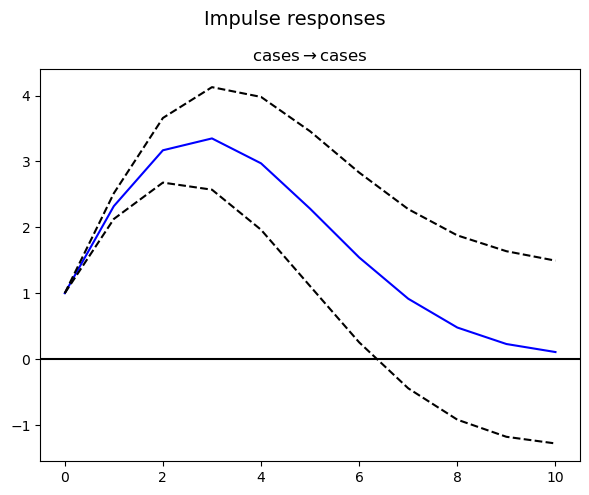

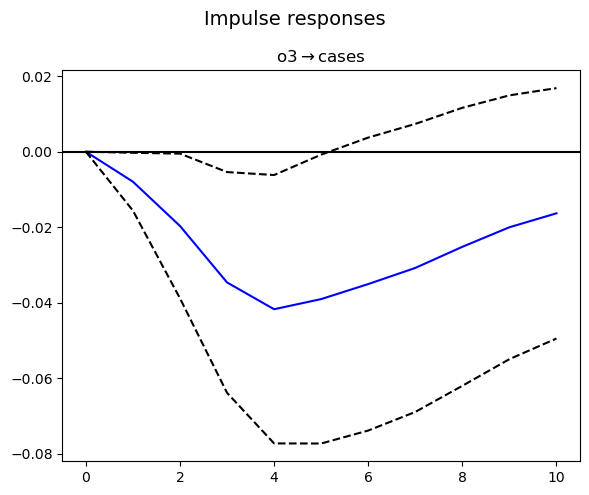

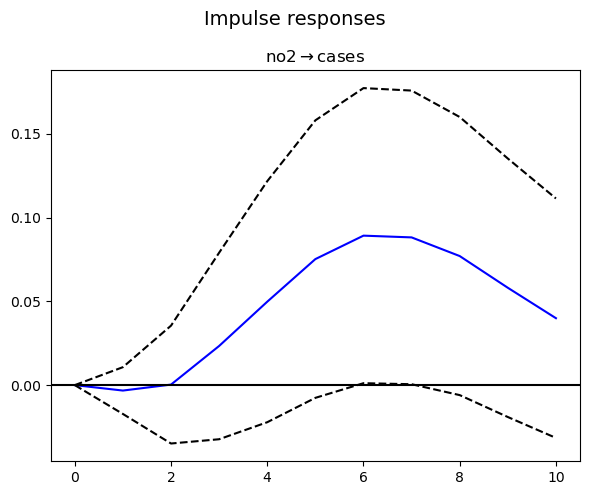

In [139]:
impulses = ['cases', 'o3', 'no2']
response = target  # e.g., 'cases'

for imp in impulses:
    irf.plot(impulse=imp, response=response, figsize=(6, 5))  # smaller plot size
    plt.tight_layout()

    


# Train Test split

Processing country: Chile
Processing country: Colombia
Processing country: Italy
Processing country: Mexico
Processing country: US


c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequ

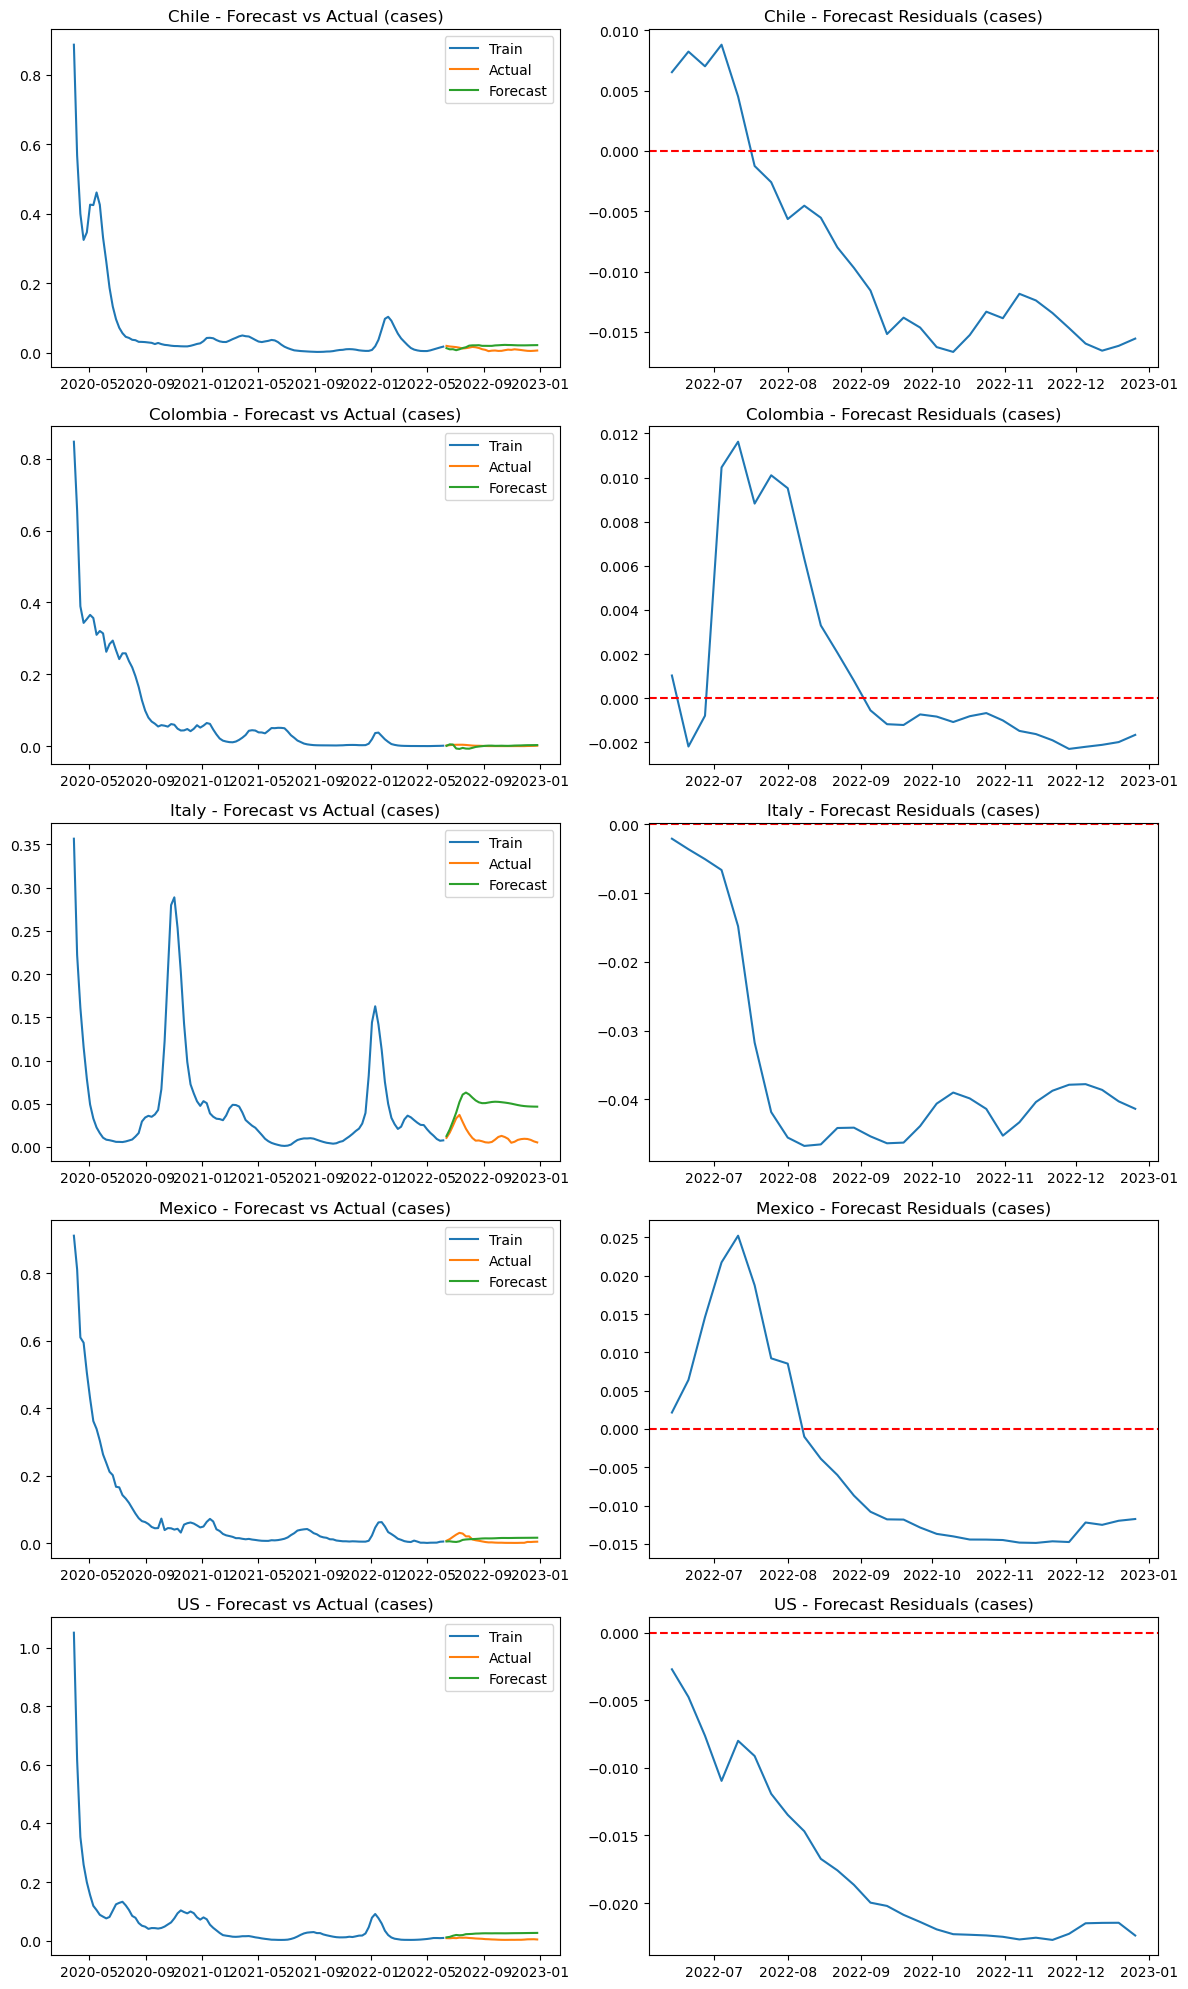

In [145]:
from sklearn.metrics import mean_squared_error, r2_score

countries = df['country'].unique()

dict_metrics = {}
target = 'cases'

fig, axs = plt.subplots(len(countries), 2, figsize=(12, 4 * len(countries)))

for idx, country in enumerate(countries):
    print(f"Processing country: {country}")

    # filter by country
    df_var = df[df['country'] == country]

    # select columns
    df_var = df_var[['date', target, 'pm25', 'no2', 'o3', 'Mean_distance_avg_14day_movavg', 'StringencyIndex_Average', 'pop_vaccinated']]
    df_var.set_index('date', inplace=True)

    # replace 0 to avoid log error
    df_var.replace(0, 0.1, inplace=True)

    # log difference
    df_var_log = np.log(df_var).diff().dropna()

    # train-test split
    split_idx = int(len(df_var_log) * 0.8)
    df_train, df_test = df_var_log.iloc[:split_idx], df_var_log.iloc[split_idx:]

    # fit VAR model on training data
    model_l = VAR(df_train)
    results_l = model_l.fit(maxlags=5)

    # Forecasting
    lag_order = results_l.k_ar
    forecast_input = df_train.values[-lag_order:]
    forecast_steps = len(df_test)

    forecast = results_l.forecast(y=forecast_input, steps=forecast_steps)
    forecast_df = pd.DataFrame(forecast, index=df_test.index, columns=df_test.columns)

    # Calculate performance metrics
    rmse = np.sqrt(mean_squared_error(df_test[target], forecast_df[target]))
    r2 = r2_score(df_test[target], forecast_df[target])

    dict_metrics[country] = {'rmse': rmse, 'r2': r2}

    # Plot actual vs forecast for target variable
    axs[idx, 0].plot(df_train[target], label='Train')
    axs[idx, 0].plot(df_test[target], label='Actual')
    axs[idx, 0].plot(forecast_df[target], label='Forecast')
    axs[idx, 0].set_title(f'{country} - Forecast vs Actual ({target})')
    axs[idx, 0].legend()

    # Plot residuals
    residuals = df_test[target] - forecast_df[target]
    axs[idx, 1].plot(residuals)
    axs[idx, 1].axhline(y=0, color='r', linestyle='--')
    axs[idx, 1].set_title(f'{country} - Forecast Residuals ({target})')

plt.tight_layout()
plt.show()

In [146]:
# Display metrics
metrics_df = pd.DataFrame(dict_metrics).T
metrics_df

,rmse,r2
Chile,0.011952,-5.815888
Colombia,0.004605,-10.728618
Italy,0.038442,-19.629045
Mexico,0.013177,-1.182547
US,0.018515,-49.652496


Processing country: Chile
Processing country: Colombia
Processing country: Italy
Processing country: Mexico
Processing country: US


c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequ

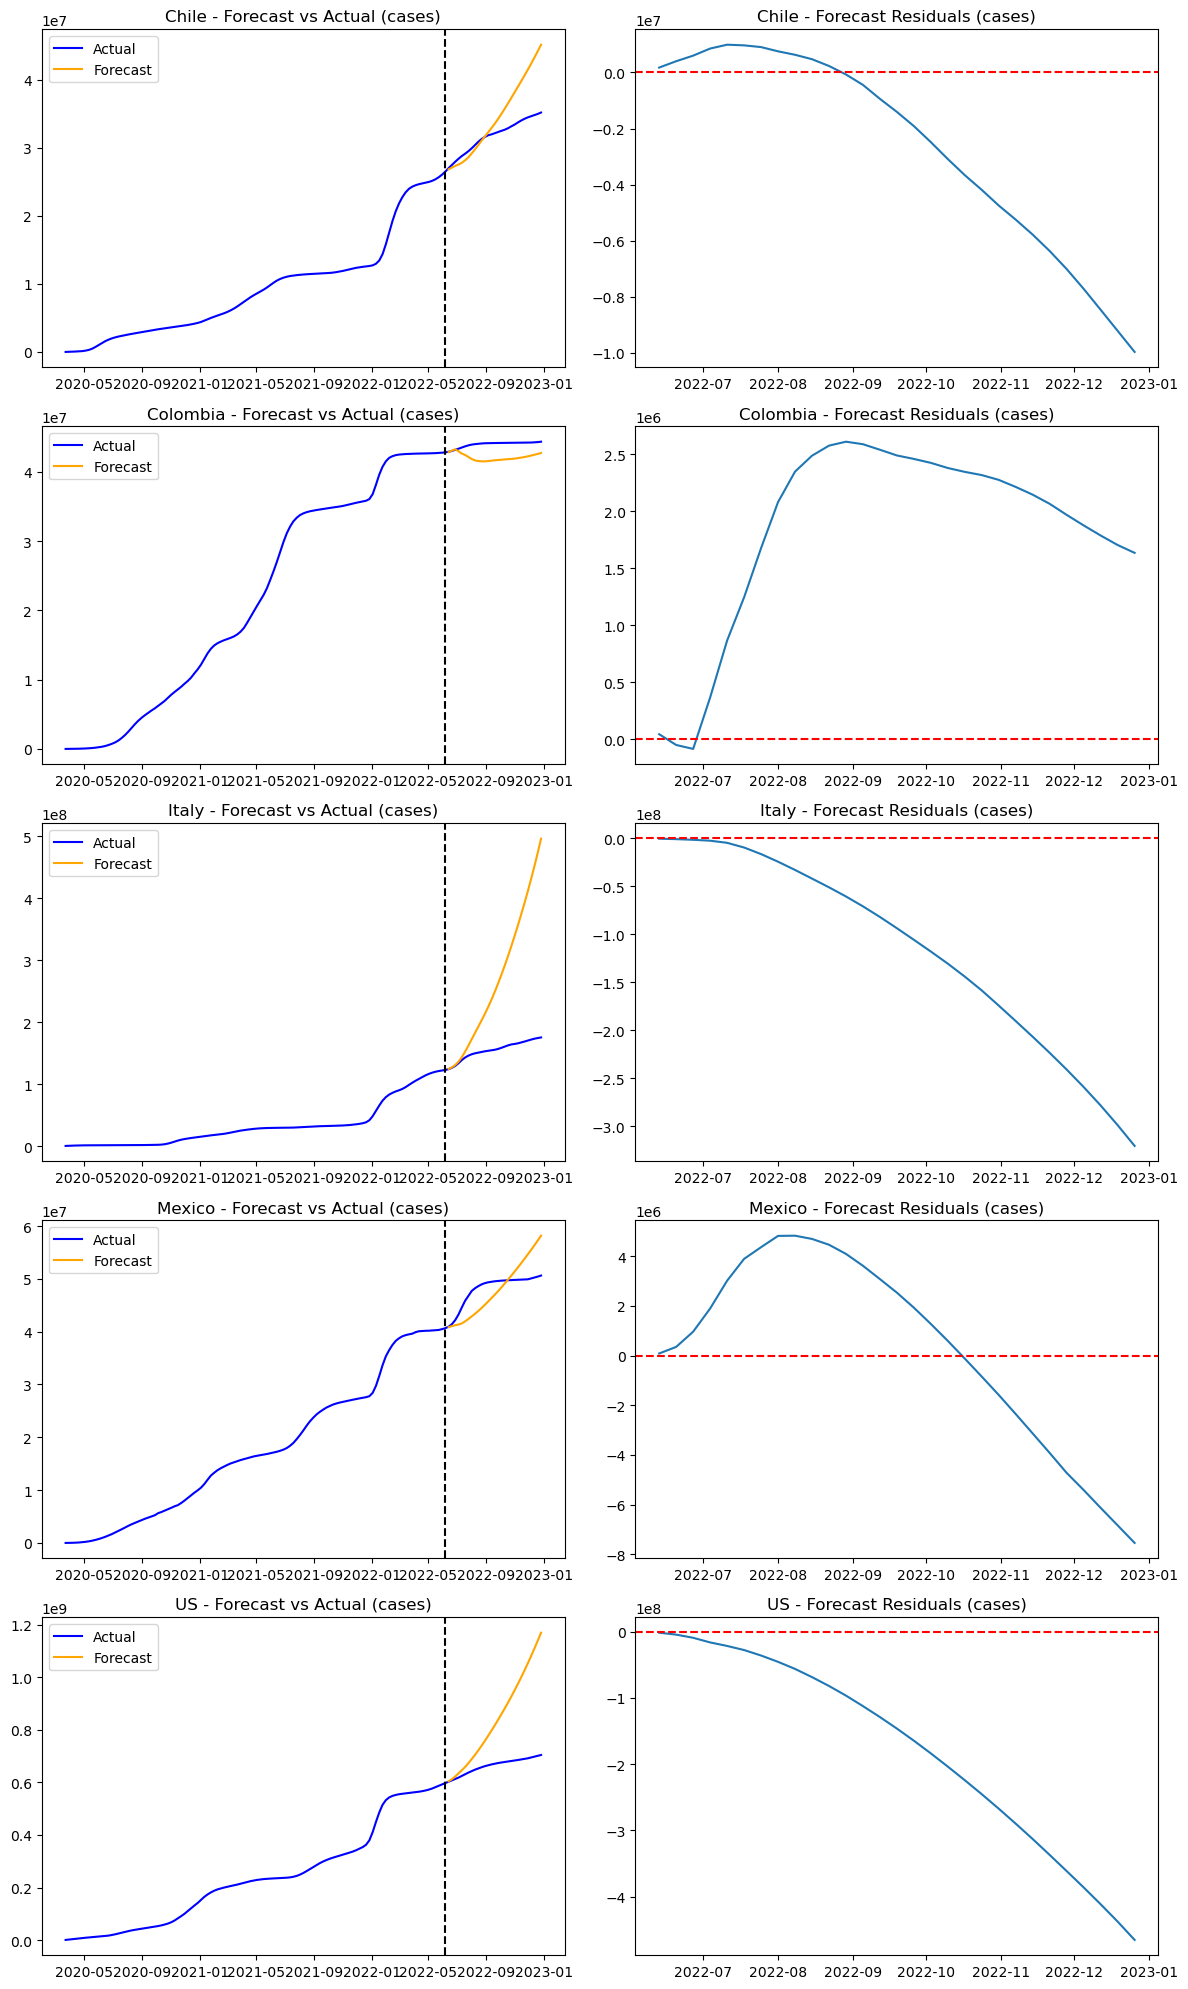

In [148]:
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

countries = df['country'].unique()

dict_metrics = {}
target = 'cases'

fig, axs = plt.subplots(len(countries), 2, figsize=(12, 4 * len(countries)))

for idx, country in enumerate(countries):
    print(f"Processing country: {country}")

    # filter by country
    df_var = df[df['country'] == country]

    # select columns
    df_var = df_var[['date', target, 'pm25', 'no2', 'o3', 'Mean_distance_avg_14day_movavg', 'StringencyIndex_Average', 'pop_vaccinated']]
    df_var.set_index('date', inplace=True)

    # replace 0 to avoid log error
    df_var.replace(0, 0.1, inplace=True)

    df_original = df_var.copy()

    # log difference
    df_var_log = np.log(df_var).diff().dropna()

    # train-test split
    split_idx = int(len(df_var_log) * 0.8)
    df_train, df_test = df_var_log.iloc[:split_idx], df_var_log.iloc[split_idx:]

    # fit VAR model on training data
    model_l = VAR(df_train)
    results_l = model_l.fit(maxlags=5)

    # Forecasting
    lag_order = results_l.k_ar
    forecast_input = df_train.values[-lag_order:]
    forecast_steps = len(df_test)

    forecast_diff_log = results_l.forecast(y=forecast_input, steps=forecast_steps)
    forecast_diff_log_df = pd.DataFrame(forecast_diff_log, index=df_test.index, columns=df_test.columns)

    # Reverse transformations to original scale
    last_observed_log = np.log(df_original.iloc[split_idx])
    forecast_log = forecast_diff_log_df.cumsum() + last_observed_log
    forecast_original_scale = np.exp(forecast_log)
    actual_original_scale = df_original.iloc[split_idx+1:split_idx+1+forecast_steps]

    # Calculate performance metrics on original scale
    rmse = np.sqrt(mean_squared_error(actual_original_scale[target], forecast_original_scale[target]))
    r2 = r2_score(actual_original_scale[target], forecast_original_scale[target])

    dict_metrics[country] = {'rmse': rmse, 'r2': r2}

    # Plot actual vs forecast for target variable in original scale
    axs[idx, 0].plot(df_original[target], label='Actual', color='blue')
    axs[idx, 0].plot(forecast_original_scale[target], label='Forecast', color='orange')
    axs[idx, 0].axvline(df_original.index[split_idx], color='black', linestyle='--')
    axs[idx, 0].set_title(f'{country} - Forecast vs Actual ({target})')
    axs[idx, 0].legend()

    # Plot residuals in original scale
    residuals = actual_original_scale[target] - forecast_original_scale[target]
    axs[idx, 1].plot(residuals)
    axs[idx, 1].axhline(y=0, color='r', linestyle='--')
    axs[idx, 1].set_title(f'{country} - Forecast Residuals ({target})')

plt.tight_layout()
plt.show()

In [149]:
# Display metrics
metrics_df = pd.DataFrame(dict_metrics).T
metrics_df

,rmse,r2
Chile,4.344672e+06,-2.344208
Colombia,2.015265e+06,-25.539846
Italy,1.523316e+08,-114.071026
Mexico,3.783188e+06,-0.806950
US,2.288078e+08,-60.252236


Processing country: Chile
Processing country: Colombia
Processing country: Italy
Processing country: Mexico
Processing country: US


c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequ

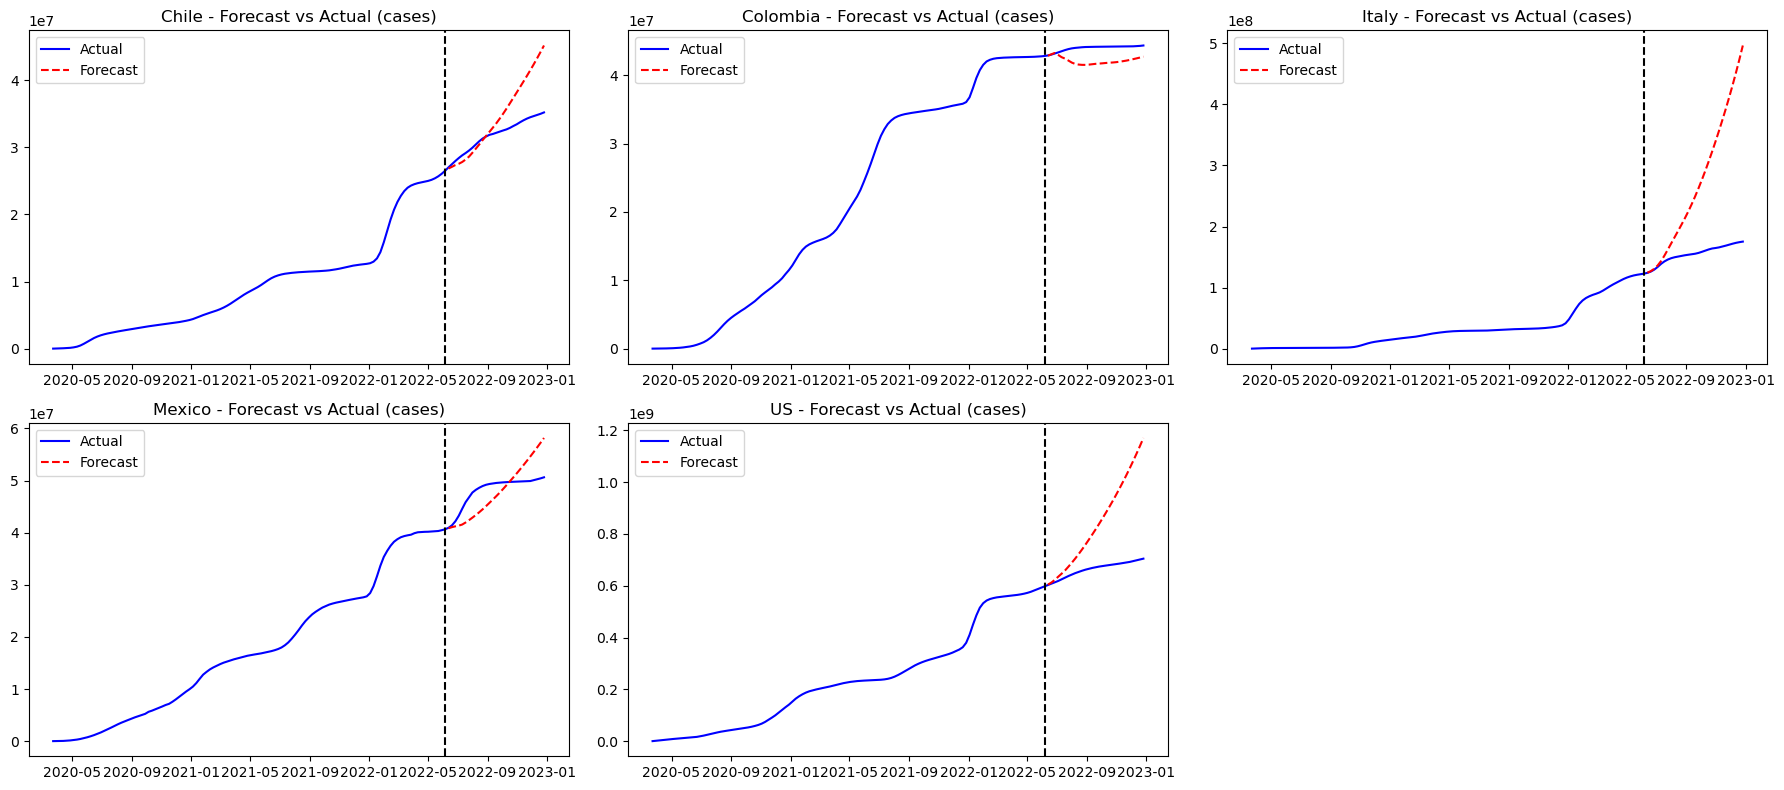

In [152]:
countries = df['country'].unique()

dict_metrics = {}
target = 'cases'

fig, axs = plt.subplots(2, 3, figsize=(18, 8))
axs = axs.flatten()

for idx, country in enumerate(countries):
    print(f"Processing country: {country}")

    # filter by country
    df_var = df[df['country'] == country]

    # select columns
    df_var = df_var[['date', target, 'pm25', 'no2', 'o3', 'Mean_distance_avg_14day_movavg', 'StringencyIndex_Average', 'pop_vaccinated']]
    df_var.set_index('date', inplace=True)

    # replace 0 to avoid log error
    df_var.replace(0, 0.1, inplace=True)

    df_original = df_var.copy()

    # log difference
    df_var_log = np.log(df_var).diff().dropna()

    # train-test split
    split_idx = int(len(df_var_log) * 0.8)
    df_train, df_test = df_var_log.iloc[:split_idx], df_var_log.iloc[split_idx:]

    # fit VAR model on training data
    model_l = VAR(df_train)
    results_l = model_l.fit(maxlags=5)

    # Forecasting
    lag_order = results_l.k_ar
    forecast_input = df_train.values[-lag_order:]
    forecast_steps = len(df_test)

    forecast_diff_log = results_l.forecast(y=forecast_input, steps=forecast_steps)
    forecast_diff_log_df = pd.DataFrame(forecast_diff_log, index=df_test.index, columns=df_test.columns)

    # Reverse transformations to original scale
    last_observed_log = np.log(df_original.iloc[split_idx])
    forecast_log = forecast_diff_log_df.cumsum() + last_observed_log
    forecast_original_scale = np.exp(forecast_log)
    actual_original_scale = df_original.iloc[split_idx+1:split_idx+1+forecast_steps]

    # Calculate performance metrics on original scale
    rmse = np.sqrt(mean_squared_error(actual_original_scale[target], forecast_original_scale[target]))
    r2 = r2_score(actual_original_scale[target], forecast_original_scale[target])

    dict_metrics[country] = {'rmse': rmse, 'r2': r2}

    # Plot actual vs forecast for target variable in original scale
    axs[idx].plot(df_original[target], label='Actual', color='blue')
    axs[idx].plot(forecast_original_scale[target], label='Forecast', color='red', linestyle='--')
    axs[idx].axvline(df_original.index[split_idx], color='black', linestyle='--')
    axs[idx].set_title(f'{country} - Forecast vs Actual ({target})')
    axs[idx].legend()

# Adjust layout and remove any unused subplots
for j in range(len(countries), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

In [154]:
# Display metrics
metrics_df = pd.DataFrame(dict_metrics).T
metrics_df[['rmse']]

,rmse
Chile,4.344672e+06
Colombia,2.015265e+06
Italy,1.523316e+08
Mexico,3.783188e+06
US,2.288078e+08


## Hybrid model

1. Fit a GGM on each country
2. Use that as a covariate 
3. Fit a VAR using the GGM fitted values as covariate
4. See the results